Sample size (n)      = 36
Sample mean (x-bar)  = 496.67 g
Standard error       = 1.3333
Z statistic          = -2.5000
Critical value       = ±1.96
p-value              = 0.0124

Decision: |Z| > 1.96 -> Reject H0
Interpretation: The machine is NOT filling 500 g on average. It needs adjustment.


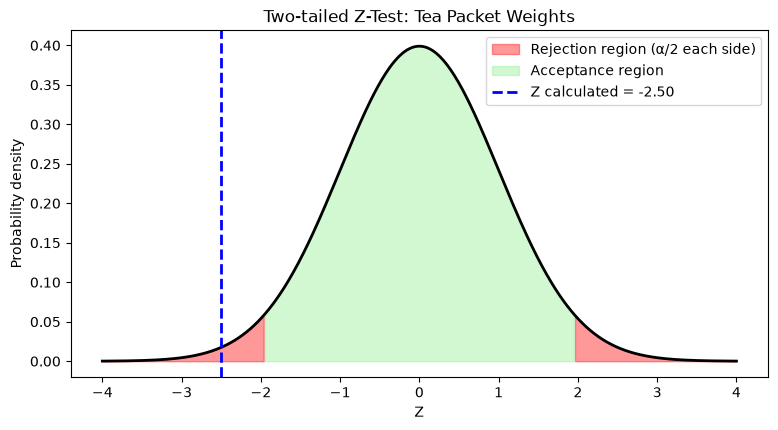

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# Step 1: Data - weights (g) of 36 packets
weights = np.array([
    495, 498, 492, 501, 497, 494, 499, 496, 503, 490, 497, 500,
    493, 498, 495, 502, 491, 497, 499, 494, 496, 500, 492, 498,
    497, 495, 501, 493, 496, 499, 494, 498, 502, 495, 497, 496
])

mu0 = 500        # claimed mean
sigma = 8        # known population SD
alpha = 0.05
n = len(weights)

x_bar = weights.mean()

# Step 2: Z statistic
se = sigma / np.sqrt(n)
z = (x_bar - mu0) / se

# Step 3: Critical value and p-value (two-tailed)
z_critical = stats.norm.ppf(1 - alpha / 2)
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"Sample size (n)      = {n}")
print(f"Sample mean (x-bar)  = {x_bar:.2f} g")
print(f"Standard error       = {se:.4f}")
print(f"Z statistic          = {z:.4f}")
print(f"Critical value       = ±{z_critical:.2f}")
print(f"p-value              = {p_value:.4f}")

# Step 4: Decision rule
if abs(z) > z_critical:
    print("\nDecision: |Z| > 1.96 -> Reject H0")
    print("Interpretation: The machine is NOT filling 500 g on average. It needs adjustment.")
else:
    print("\nDecision: |Z| <= 1.96 -> Fail to reject H0")
    print("Interpretation: The machine is filling 500 g on average.")

# Step 5: Graph - standard normal curve with rejection regions
x = np.linspace(-4, 4, 500)
y = stats.norm.pdf(x)

plt.figure(figsize=(9, 4.5))

plt.plot(x, y, 'k', lw=2)

# Left rejection region
plt.fill_between(
    x,
    y,
    where=(x <= -z_critical),
    color='red',
    alpha=0.4,
    label='Rejection region (α/2 each side)'
)

# Right rejection region
plt.fill_between(
    x,
    y,
    where=(x >= z_critical),
    color='red',
    alpha=0.4
)

# Acceptance region
plt.fill_between(
    x,
    y,
    where=(abs(x) < z_critical),
    color='lightgreen',
    alpha=0.4,
    label='Acceptance region'
)

# Calculated Z
plt.axvline(
    z,
    color='blue',
    linestyle='--',
    lw=2,
    label=f'Z calculated = {z:.2f}'
)

plt.title('Two-tailed Z-Test: Tea Packet Weights')
plt.xlabel('Z')
plt.ylabel('Probability density')
plt.legend()

plt.show()